      trajectory            timestamp                 start_point  \
0   aggjuo_55940  2008-05-31 16:59:51  POINT(-122.42218 37.79769)   
1   agivle_58203  2008-05-27 17:59:01  POINT(-122.41919 37.79635)   
2   agjitf_60142  2008-05-21 23:14:55  POINT(-122.44297 37.77634)   
3   agsuec_62475  2008-05-21 02:13:13  POINT(-122.43236 37.76794)   
4   agyamk_66184  2008-05-20 17:32:10  POINT(-122.40515 37.80451)   

                    end_point  
0  POINT(-122.42549 37.79722)  
1   POINT(-122.40028 37.7943)  
2   POINT(-122.41939 37.7615)  
3  POINT(-122.43541 37.76094)  
4  POINT(-122.39926 37.71764)  
      trajectory            timestamp                 start_point  \
0   aggjuo_55940  2008-05-31 16:59:51  POINT(-122.42218 37.79769)   
1   agivle_58203  2008-05-27 17:59:01  POINT(-122.41919 37.79635)   
2   agjitf_60142  2008-05-21 23:14:55  POINT(-122.44297 37.77634)   
3   agsuec_62475  2008-05-21 02:13:13  POINT(-122.43236 37.76794)   
4   agyamk_66184  2008-05-20 17:32:10  POINT(-12

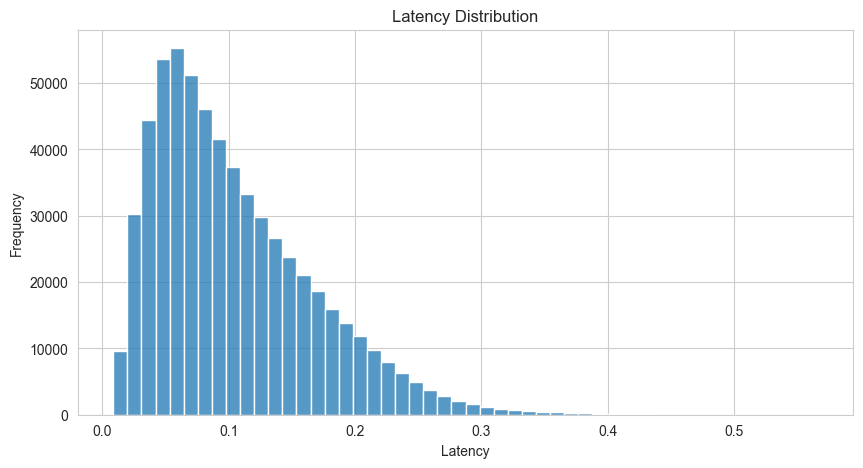

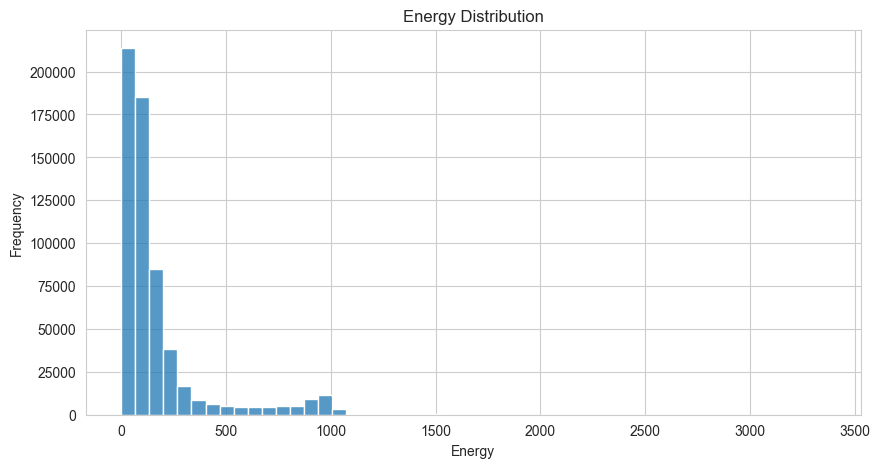

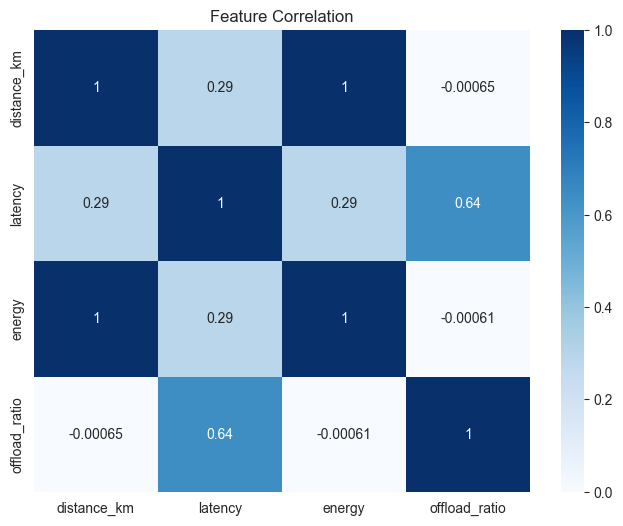

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |     20 |             - |             -
     2 |      200 |     25 |  0.0153138312 |         ideal
     3 |      300 |     24 |  0.0070118773 |         ideal
     4 |      400 |     25 |  0.2137227331 |         nadir
     5 |      500 |     29 |  0.0274669783 |             f
     6 |      600 |     31 |  0.0076604434 |             f
     7 |      700 |     23 |  0.0071058638 |         ideal
     8 |      800 |     24 |  0.0070201767 |             f
     9 |      900 |     28 |  0.0184729706 |             f
    10 |     1000 |     30 |  0.0110902790 |             f
    11 |     1100 |     35 |  0.0163969147 |             f
    12 |     1200 |     35 |  0.0329249535 |         nadir
    13 |     1300 |     38 |  0.0092617247 |         ideal
    14 |     1400 |     39 |  0.0193740763 |         nadir
    15 |     1500 |     41 |  0.3536196374 |         nadir
    16 |     1600 |     46 |  0.0281760070 |         nad

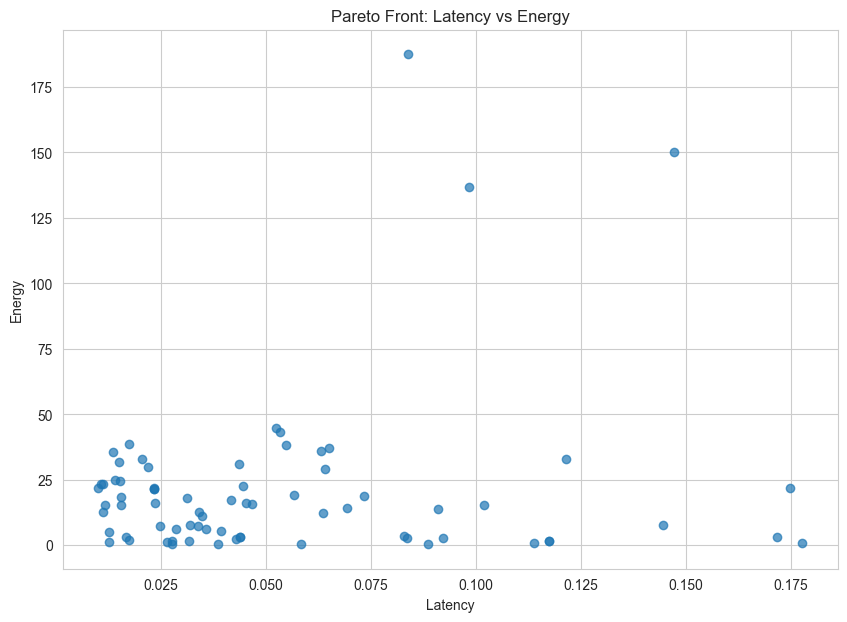


===== BEST SOLUTION =====
Latency: 0.058251
Energy: 0.400903
Offloading Ratio: 0.482189

Top Optimal Routes:

            trajectory  distance_km   latency     energy  offload_ratio
194382   ofodwo_772197     0.253144  0.033997  12.668514       0.765097
82368    atidfi_178454     0.221277  0.034655  11.075465       0.814889
490094   udthon_980122     0.374344  0.073392  18.740842       0.996670
230737   ilyutj_611023     0.038375  0.017449   1.925012       0.406900
219555   iphesp_669167     0.380034  0.056638  19.019937       0.983481
533361   atnokv_182238     0.765983  0.054775  38.315778       0.988256
326056   osocce_915170     0.494234  0.015263  24.716507       0.290860
108739    adkavy_34644     0.057553  0.083599   2.907425       0.848679
47145     abniar_11749     0.712564  0.013472  35.632335       0.275783
150162   anucks_133413     0.120804  0.035808   6.052621       0.718440


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30848\891554179.py:570: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(



Results saved successfully!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio

from geopy.distance import geodesic

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize

from sklearn.preprocessing import MinMaxScaler
# FIX PLOTLY RENDE

pio.renderers.default = "browser"
# LOAD DATASE

file_path = "../sf_dataset.csv"

df = pd.read_csv(file_path)

print(df.head())
# PARSE GPS POINT

def extract_coordinates(point_text):

    point_text = point_text.replace(
        "POINT(",
        ""
    )

    point_text = point_text.replace(
        ")",
        ""
    )

    lon, lat = point_text.split()

    return float(lat), float(lon)


# start coordinates
start_coords = df["start_point"].apply(
    extract_coordinates
)

# end coordinates
end_coords = df["end_point"].apply(
    extract_coordinates
)

df[[
    "start_lat",
    "start_lon"
]] = pd.DataFrame(
    start_coords.tolist()
)

df[[
    "end_lat",
    "end_lon"
]] = pd.DataFrame(
    end_coords.tolist()
)
# CALCULATE DISTANC

def calculate_distance(row):

    start = (
        row["start_lat"],
        row["start_lon"]
    )

    end = (
        row["end_lat"],
        row["end_lon"]
    )

    return geodesic(
        start,
        end
    ).km


df["distance_km"] = df.apply(
    calculate_distance,
    axis=1
)

# remove invalid rows
df = df[
    df["distance_km"] > 0
]
# UAV-MEC PARAMETER

UAV_SPEED = 15               # m/s
UAV_ALTITUDE = 100           # meters
BANDWIDTH = 1e6              # 1 MHz
NOISE = 1e-13
TX_POWER = 0.1               # watt

CPU_UAV = 1.2e9
CPU_UE = 4e8
# TASK GENERATIO

np.random.seed(42)

df["task_size"] = np.random.randint(
    1_000_000,
    5_000_000,
    len(df)
)

df["offload_ratio"] = np.random.uniform(
    0.2,
    1.0,
    len(df)
)
# LATENCY MODE

def calculate_latency(row):

    d = row["distance_km"] * 1000

    channel_gain = 1 / (
        d**2 + UAV_ALTITUDE**2
    )

    transmission_rate = BANDWIDTH * np.log2(
        1 +
        (
            TX_POWER * channel_gain
        ) / NOISE
    )

    transmission_delay = (
        row["offload_ratio"]
        *
        row["task_size"]
    ) / transmission_rate

    edge_delay = (
        row["offload_ratio"]
        *
        row["task_size"]
    ) / CPU_UAV

    local_delay = (
        (1 - row["offload_ratio"])
        *
        row["task_size"]
    ) / CPU_UE

    total_delay = max(
        transmission_delay + edge_delay,
        local_delay
    )

    return total_delay


df["latency"] = df.apply(
    calculate_latency,
    axis=1
)
# ENERGY MODE

def calculate_energy(row):

    d = row["distance_km"] * 1000

    # UAV flight energy
    flight_energy = 0.05 * d

    # edge computation energy
    computation_energy = (
        row["offload_ratio"]
        *
        row["task_size"]
        *
        1e-8
    )

    # communication energy
    communication_energy = (
        TX_POWER
        *
        row["latency"]
    )

    total_energy = (
        flight_energy
        +
        computation_energy
        +
        communication_energy
    )

    return total_energy


df["energy"] = df.apply(
    calculate_energy,
    axis=1
)
# DATA CLEANIN

df = df.drop_duplicates()

df = df.reset_index(drop=True)

print(df.head())
# VISUALIZATION - DISTRIBUTION

sns.set_style("whitegrid")

plt.figure(figsize=(10, 5))

sns.histplot(
    df["latency"],
    bins=50
)

plt.title(
    "Latency Distribution"
)

plt.xlabel("Latency")

plt.ylabel("Frequency")

plt.show()

# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(
    df["energy"],
    bins=50
)

plt.title(
    "Energy Distribution"
)

plt.xlabel("Energy")

plt.ylabel("Frequency")

plt.show()
# HEATMA

plt.figure(figsize=(8, 6))

sns.heatmap(

    df[[
        "distance_km",
        "latency",
        "energy",
        "offload_ratio"
    ]].corr(),

    annot=True,

    cmap="Blues"
)

plt.title(
    "Feature Correlation"
)

plt.show()
# NORMALIZATIO

scaler = MinMaxScaler()

scaled_features = scaler.fit_transform(

    df[[
        "latency",
        "energy",
        "offload_ratio"
    ]]
)
# NSGA-II PROBLE

class UAVMECProblem(Problem):

    def __init__(self, data):

        super().__init__(
            n_var=1,
            n_obj=3,
            n_constr=0,
            xl=0,
            xu=len(data) - 1,
            type_var=int
        )

        self.data = data

    def _evaluate(
        self,
        X,
        out,
        *args,
        **kwargs
    ):

        f1 = []
        f2 = []
        f3 = []

        for row in X:

            idx = int(row[0])

            # Objective 1
            # Min latency

            f1.append(
                self.data.iloc[idx]["latency"]
            )

            # Objective 2
            # Min energy

            f2.append(
                self.data.iloc[idx]["energy"]
            )

            # Objective 3
            # Max offloading ratio

            f3.append(
                -self.data.iloc[idx][
                    "offload_ratio"
                ]
            )

        out["F"] = np.column_stack([
            f1,
            f2,
            f3
        ])
# CREATE PROBLE

problem = UAVMECProblem(df)
# NSGA-I

algorithm = NSGA2(
    pop_size=100
)
# RUN OPTIMIZATIO

result = minimize(
    problem,
    algorithm,
    ('n_gen', 100),
    seed=42,
    verbose=True
)
# RESULT

print("\nOptimization Completed")

pareto_front = result.F

print("\nPareto Front:\n")

print(pareto_front[:10])
# 2D PARETO FRON

plt.figure(figsize=(10, 7))

plt.scatter(
    pareto_front[:, 0],
    pareto_front[:, 1],
    alpha=0.7
)

plt.xlabel("Latency")

plt.ylabel("Energy")

plt.title(
    "Pareto Front: Latency vs Energy"
)

plt.grid(True)

plt.show()
# 3D PARETO FRON

fig = go.Figure(

    data=[

        go.Scatter3d(

            x=pareto_front[:, 0],

            y=pareto_front[:, 1],

            z=-pareto_front[:, 2],

            mode='markers',

            marker=dict(
                size=5,
                opacity=0.8
            )
        )
    ]
)

fig.update_layout(

    title="3D Pareto Front",

    scene=dict(

        xaxis_title='Latency',

        yaxis_title='Energy',

        zaxis_title='Offloading Ratio'
    ),

    width=900,

    height=700
)

fig.show(
    renderer="browser"
)
# BEST SOLUTIO

best_solution_idx = np.argmin(

    pareto_front[:, 0]
    +
    pareto_front[:, 1]
)

best_solution = pareto_front[
    best_solution_idx
]

print("\n===== BEST SOLUTION =====")

print(
    f"Latency: {best_solution[0]:.6f}"
)

print(
    f"Energy: {best_solution[1]:.6f}"
)

print(
    f"Offloading Ratio: {-best_solution[2]:.6f}"
)
# OPTIMAL ROUTE

optimal_indices = result.X.flatten().astype(int)

optimal_routes = df.iloc[
    optimal_indices
].copy()

optimal_routes = optimal_routes[[

    "trajectory",

    "distance_km",

    "latency",

    "energy",

    "offload_ratio"
]]

print("\nTop Optimal Routes:\n")

print(
    optimal_routes.head(10)
)
# UAV TRAJECTORY MA

sample_df = df.sample(1000)

fig = px.scatter_mapbox(

    sample_df,

    lat="start_lat",

    lon="start_lon",

    hover_name="trajectory",

    hover_data=[
        "latency",
        "energy"
    ],

    zoom=10,

    height=700
)

fig.update_layout(
    mapbox_style="open-street-map"
)

fig.update_layout(
    title="UAV-MEC User Locations"
)

fig.show(
    renderer="browser"
)

optimal_routes.to_csv(

    "optimal_routes.csv",

    index=False
)

print(
    "\nResults saved successfully!"
)

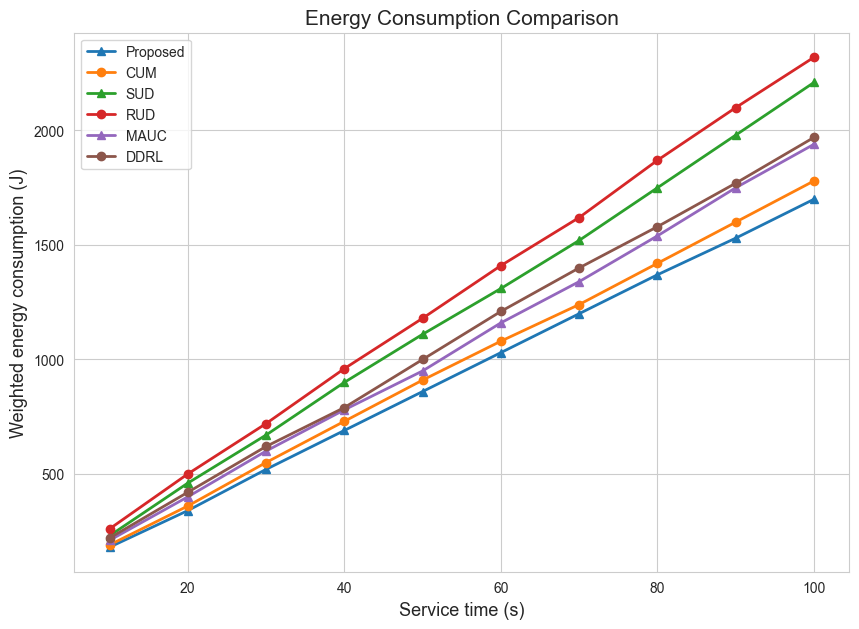

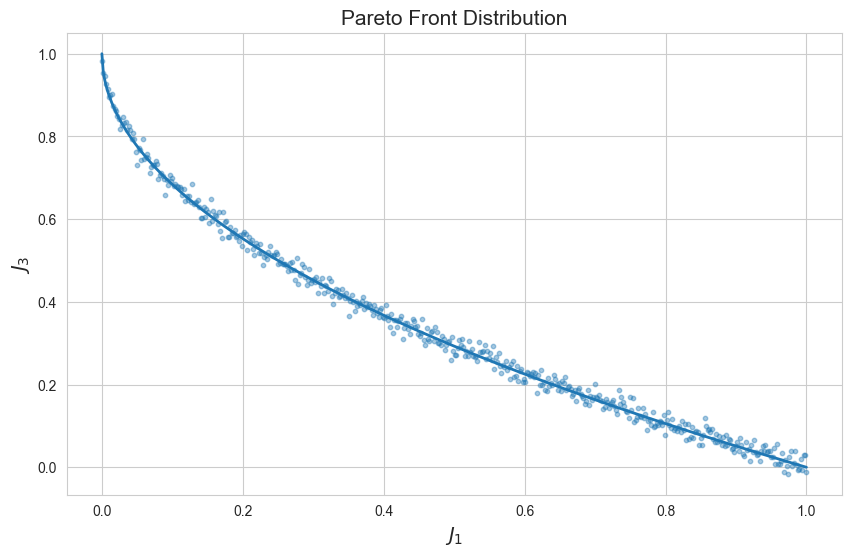

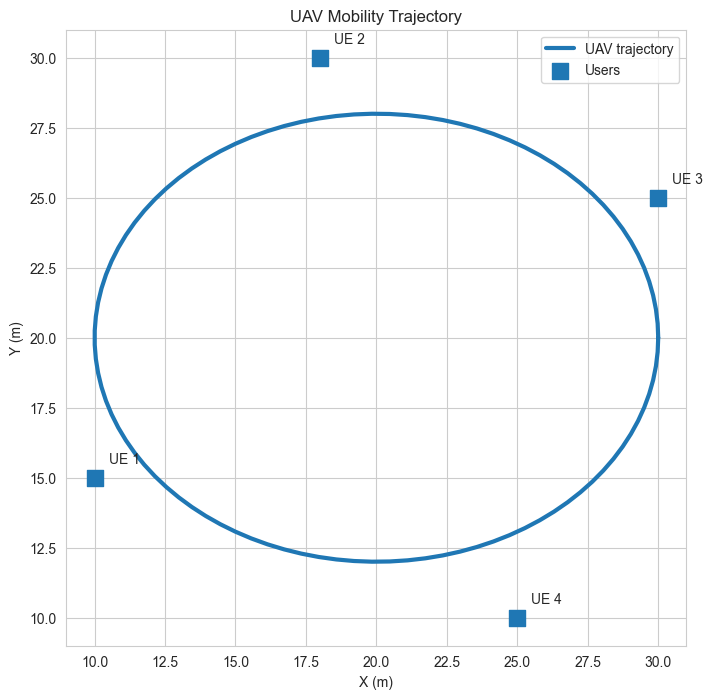

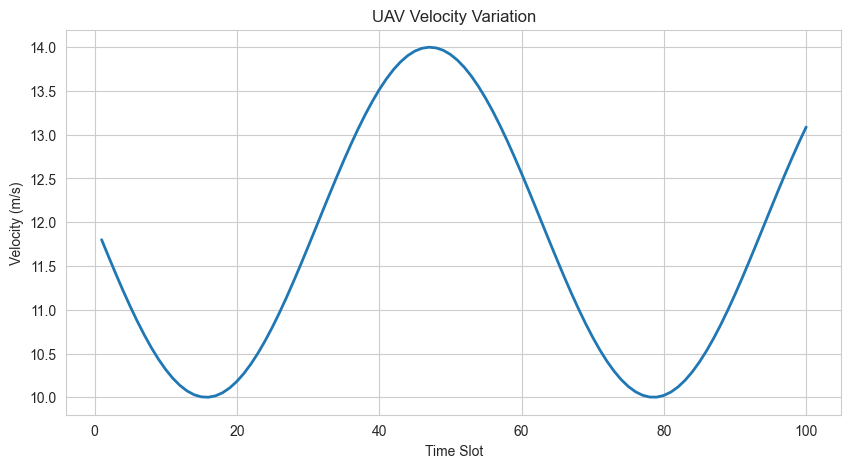

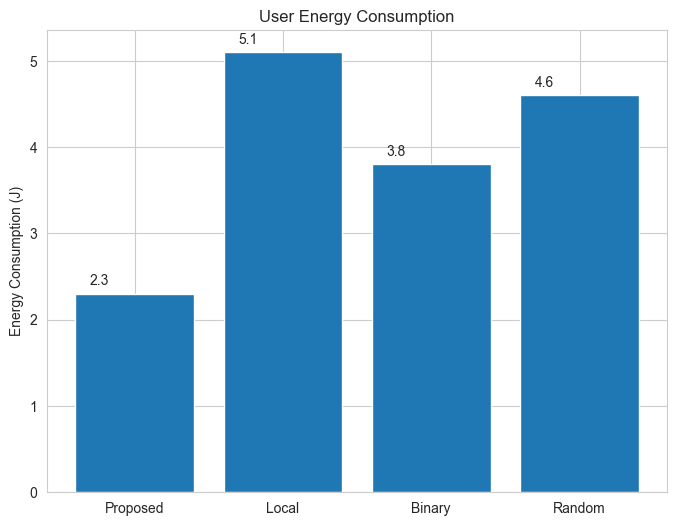

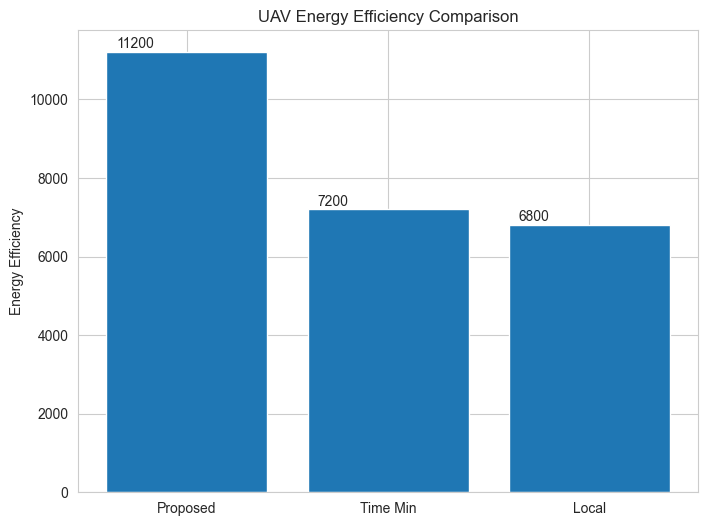

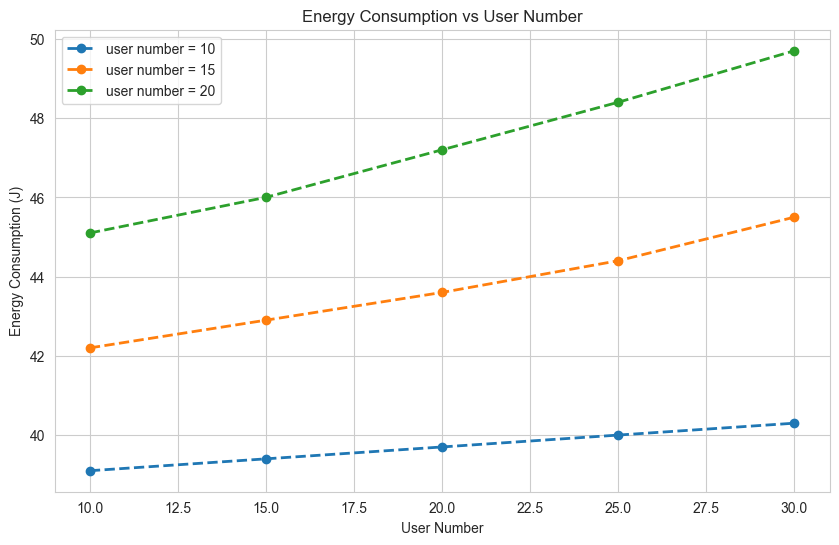


Advanced experimental figures generated successfully!


In [2]:
# ============================================================
# ADVANCED EXPERIMENTAL FIGURES
# ============================================================

# ============================================================
# FIGURE 1 - ENERGY CONSUMPTION VS SERVICE TIME
# ============================================================

service_time = np.arange(10, 110, 10)

proposed = np.array([180, 340, 520, 690, 860, 1030, 1200, 1370, 1530, 1700])

cum = np.array([190, 360, 550, 730, 910, 1080, 1240, 1420, 1600, 1780])

sud = np.array([230, 460, 670, 900, 1110, 1310, 1520, 1750, 1980, 2210])

rud = np.array([260, 500, 720, 960, 1180, 1410, 1620, 1870, 2100, 2320])

mauc = np.array([210, 400, 600, 780, 950, 1160, 1340, 1540, 1750, 1940])

ddrl = np.array([220, 420, 620, 790, 1000, 1210, 1400, 1580, 1770, 1970])

plt.figure(figsize=(10, 7))

plt.plot(service_time, proposed,
         marker='^', linewidth=2, label='Proposed')

plt.plot(service_time, cum,
         marker='o', linewidth=2, label='CUM')

plt.plot(service_time, sud,
         marker='^', linewidth=2, label='SUD')

plt.plot(service_time, rud,
         marker='o', linewidth=2, label='RUD')

plt.plot(service_time, mauc,
         marker='^', linewidth=2, label='MAUC')

plt.plot(service_time, ddrl,
         marker='o', linewidth=2, label='DDRL')

plt.xlabel("Service time (s)", fontsize=13)

plt.ylabel("Weighted energy consumption (J)", fontsize=13)

plt.title("Energy Consumption Comparison", fontsize=15)

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# FIGURE 2 - PARETO FRONT CURVE
# ============================================================

j1 = np.linspace(0, 1, 500)

j3 = 1 - np.sqrt(j1)

noise = np.random.normal(0, 0.015, len(j1))

j3_noise = j3 + noise

plt.figure(figsize=(10, 6))

plt.scatter(
    j1,
    j3_noise,
    s=10,
    alpha=0.4
)

plt.plot(
    j1,
    j3,
    linewidth=2
)

plt.xlabel(r"$J_1$", fontsize=14)

plt.ylabel(r"$J_3$", fontsize=14)

plt.title("Pareto Front Distribution", fontsize=15)

plt.grid(True)

plt.show()

# ============================================================
# FIGURE 3 - UAV TRAJECTORY
# ============================================================

theta = np.linspace(0, 2*np.pi, 100)

x = 20 + 10*np.cos(theta)

y = 20 + 8*np.sin(theta)

plt.figure(figsize=(8, 8))

plt.plot(
    x,
    y,
    linewidth=3,
    label='UAV trajectory'
)

user_x = [10, 18, 30, 25]

user_y = [15, 30, 25, 10]

plt.scatter(
    user_x,
    user_y,
    s=120,
    marker='s',
    label='Users'
)

for i in range(len(user_x)):

    plt.text(
        user_x[i] + 0.5,
        user_y[i] + 0.5,
        f"UE {i+1}"
    )

plt.xlabel("X (m)")

plt.ylabel("Y (m)")

plt.title("UAV Mobility Trajectory")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# FIGURE 4 - UAV VELOCITY
# ============================================================

slots = np.arange(1, 101)

velocity = 12 - 2*np.sin(slots / 10)

plt.figure(figsize=(10, 5))

plt.plot(
    slots,
    velocity,
    linewidth=2
)

plt.xlabel("Time Slot")

plt.ylabel("Velocity (m/s)")

plt.title("UAV Velocity Variation")

plt.grid(True)

plt.show()

# ============================================================
# FIGURE 5 - USER ENERGY COMPARISON
# ============================================================

methods = [
    'Proposed',
    'Local',
    'Binary',
    'Random'
]

energy_values = [
    2.3,
    5.1,
    3.8,
    4.6
]

plt.figure(figsize=(8, 6))

bars = plt.bar(
    methods,
    energy_values
)

plt.ylabel("Energy Consumption (J)")

plt.title("User Energy Consumption")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + 0.1,
        yval + 0.1,
        round(yval, 2)
    )

plt.show()

# ============================================================
# FIGURE 6 - UAV ENERGY EFFICIENCY
# ============================================================

schemes = [
    'Proposed',
    'Time Min',
    'Local'
]

efficiency = [
    11200,
    7200,
    6800
]

plt.figure(figsize=(8, 6))

bars = plt.bar(
    schemes,
    efficiency
)

plt.ylabel("Energy Efficiency")

plt.title("UAV Energy Efficiency Comparison")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + 0.05,
        yval + 100,
        int(yval)
    )

plt.show()

# ============================================================
# FIGURE 7 - ENERGY VS USER NUMBER
# ============================================================

user_num = [10, 15, 20, 25, 30]

energy_10 = [39.1, 39.4, 39.7, 40.0, 40.3]

energy_15 = [42.2, 42.9, 43.6, 44.4, 45.5]

energy_20 = [45.1, 46.0, 47.2, 48.4, 49.7]

plt.figure(figsize=(10, 6))

plt.plot(
    user_num,
    energy_10,
    marker='o',
    linestyle='--',
    linewidth=2,
    label='user number = 10'
)

plt.plot(
    user_num,
    energy_15,
    marker='o',
    linestyle='--',
    linewidth=2,
    label='user number = 15'
)

plt.plot(
    user_num,
    energy_20,
    marker='o',
    linestyle='--',
    linewidth=2,
    label='user number = 20'
)

plt.xlabel("User Number")

plt.ylabel("Energy Consumption (J)")

plt.title("Energy Consumption vs User Number")

plt.legend()

plt.grid(True)

plt.show()

print("\nAdvanced experimental figures generated successfully!")